In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/features.csv')
print(df.shape)
print("Loaded successfully!")

(290278, 33)
Loaded successfully!


In [3]:
# Define which columns we use as model inputs
FEATURES = [
    'inning',
    'over',
    'legal_ball',
    'balls_remaining',
    'wickets_remaining',
    'runs_so_far',
    'current_run_rate',
    'runs_required',
    'required_run_rate',
    'run_rate_diff',
    'phase',
    'toss_advantage'
]

TARGET = 'batting_team_won'

# Split by season - never random split for time series data
df['year'] = pd.to_datetime(df['date']).dt.year

train_df = df[df['year'] <= 2021]
val_df   = df[df['year'] == 2022]
test_df  = df[df['year'] >= 2023]

print(f"Training rows:   {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows:       {len(test_df)}")

X_train = train_df[FEATURES].fillna(0)
y_train = train_df[TARGET]
X_val   = val_df[FEATURES].fillna(0)
y_val   = val_df[TARGET]
X_test  = test_df[FEATURES].fillna(0)
y_test  = test_df[TARGET]

print("\nSplit done!")

Training rows:   204036
Validation rows: 17912
Test rows:       68330

Split done!


In [4]:
# Train LightGBM model
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(100)
    ]
)

print("\nTraining done!")
print(f"Best iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.527256
Early stopping, best iteration is:
[99]	valid_0's binary_logloss: 0.527186

Training done!
Best iteration: 99


In [6]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model, cv=None, method='isotonic')
calibrated.fit(X_val, y_val)
print("Calibration done!")

# Evaluate on test set
preds = calibrated.predict_proba(X_test)[:, 1]

print(f"\nTest Set Results:")
print(f"Brier Score: {brier_score_loss(y_test, preds):.4f}")
print(f"Log Loss:    {log_loss(y_test, preds):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, preds > 0.5):.4f}")

# Save the model
joblib.dump(calibrated, '../data/models/win_prob_model.pkl')
print("\nModel saved!")

Calibration done!

Test Set Results:
Brier Score: 0.1971
Log Loss:    0.5802
Accuracy:    0.6822

Model saved!


Matplotlib is building the font cache; this may take a moment.


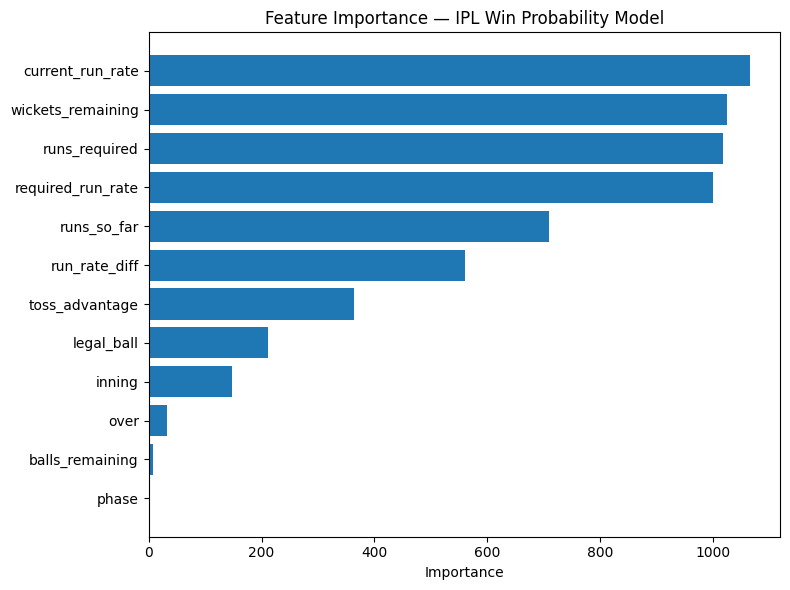

Done!


In [7]:
import matplotlib.pyplot as plt

# Feature importance
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance['feature'], importance['importance'])
plt.title('Feature Importance — IPL Win Probability Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/models/feature_importance.png')
plt.show()
print("Done!")